In [28]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
mpl.rcParams['figure.dpi'] = 150

import astropy
from astropy.table import Table, join, vstack, Column
from astropy import units as u
from astropy.coordinates import SkyCoord

import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astroquery.sdss import SDSS
import seaborn as sns

Read in data:

In [2]:
G = 20.0
tab_quaia = Table.read('../data/quaia_G{}.fits'.format(G))
print("Columns:", tab_quaia.columns)
print("N =", len(tab_quaia))

Columns: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
N = 755850


In [3]:
# tab_sdss_dr16q = Table.read('../data/SDSS_DR16Q_v4.fits')
tab_sdss_dr16q = Table.read('../data/DR16Q_v4.fits')
tab_sdss_dr16q = tab_sdss_dr16q[tab_sdss_dr16q['OBJID'].mask==False] #remove ones with no objid (1001)
print("Columns:", tab_sdss_dr16q.columns)
print("N =", len(tab_sdss_dr16q))

Columns: <TableColumns names=('SDSS_NAME','RA','DEC','PLATE','MJD','FIBERID','AUTOCLASS_PQN','AUTOCLASS_DR14Q','IS_QSO_QN','Z_QN','RANDOM_SELECT','Z_10K','Z_CONF_10K','PIPE_CORR_10K','IS_QSO_10K','THING_ID','Z_VI','Z_CONF','CLASS_PERSON','Z_DR12Q','IS_QSO_DR12Q','Z_DR7Q_SCH','IS_QSO_DR7Q','Z_DR6Q_HW','Z_DR7Q_HW','IS_QSO_FINAL','Z','SOURCE_Z','Z_PIPE','ZWARNING','OBJID','Z_PCA','ZWARN_PCA','DELTACHI2_PCA','Z_HALPHA','ZWARN_HALPHA','DELTACHI2_HALPHA','Z_HBETA','ZWARN_HBETA','DELTACHI2_HBETA','Z_MGII','ZWARN_MGII','DELTACHI2_MGII','Z_CIII','ZWARN_CIII','DELTACHI2_CIII','Z_CIV','ZWARN_CIV','DELTACHI2_CIV','Z_LYA','ZWARN_LYA','DELTACHI2_LYA','Z_LYAWG','Z_DLA','NHI_DLA','CONF_DLA','BAL_PROB','BI_CIV','ERR_BI_CIV','AI_CIV','ERR_AI_CIV','BI_SIIV','ERR_BI_SIIV','AI_SIIV','ERR_AI_SIIV','BOSS_TARGET1','EBOSS_TARGET0','EBOSS_TARGET1','EBOSS_TARGET2','ANCILLARY_TARGET1','ANCILLARY_TARGET2','NSPEC_SDSS','NSPEC_BOSS','NSPEC','PLATE_DUPLICATE','MJD_DUPLICATE','FIBERID_DUPLICATE','SPECTRO_DUPLICATE','S

Do cross-matching:

In [4]:
def cross_match(ra1, dec1, ra2, dec2, separation):
    coords1 = SkyCoord(ra=ra1, dec=dec1, frame='icrs')    
    coords2 = SkyCoord(ra=ra2, dec=dec2, frame='icrs') 
    cross = astropy.coordinates.search_around_sky(coords1, coords2, separation) 
    index_list_1in2, index_list_2in1 = cross[0], cross[1] 
    return index_list_1in2, index_list_2in1

Now let's check the downloaded SDSS DR16 catalog:

In [5]:
# Perform cross-match; 1 arcsec is a reasonable separation
separation = 1*u.arcsec
index_list_quaiaINsdssdr16q, index_list_sdssdr16qINquaia = cross_match(tab_quaia['ra'], tab_quaia['dec'],
                                                           tab_sdss_dr16q['RA']*u.degree, tab_sdss_dr16q['DEC']*u.degree,
                                                           separation=separation)

In [6]:
tab_quaia_with_sdssdr16q_match = tab_quaia[index_list_quaiaINsdssdr16q]
tab_sdssdr16q_with_quaia_match = tab_sdss_dr16q[index_list_sdssdr16qINquaia]

# Can add info from SDSS table to Quaia table, as these should have the same length now, e.g.:
for column in tab_sdss_dr16q.columns:
    tab_quaia_with_sdssdr16q_match.add_column(tab_sdssdr16q_with_quaia_match[column], name='sdss_'+column)

# Print number in each table; last two lines should be identical
print(f'Number of Quaia quasars with SDSS  DR16Q match: {len(tab_quaia_with_sdssdr16q_match)}')
print(f'Number of SDSS DR16Q sources with Gaia match: {len(tab_sdssdr16q_with_quaia_match)}')

Number of Quaia quasars with SDSS  DR16Q match: 187970
Number of SDSS DR16Q sources with Gaia match: 187970


So we got a few more here than with our SkyServer download; let's check em out

In [7]:
# tab_quaia_with_sdss_match.add_index('source_id')
tab_quaia_with_sdssdr16q_match.add_index('source_id')

So here's our final table of Quaia souces with SDSS spectra:

In [8]:
# tab_quaia_sdss_combined = join(tab_quaia_with_sdss_match, tab_quaia_with_sdssdr16q_match, keys='source_id',
#                               join_type='outer')
print(f'Number of Quaia quasars with any SDSS spectrum: {len(tab_quaia_with_sdssdr16q_match)}')

Number of Quaia quasars with any SDSS spectrum: 187970


# Calculate median G-i
## First figure out colormag for SDSS x Quaia cross matches

In [9]:
# # get cmodelmag_i 

# tabs = []
# for z in ['s.z <= 1.5', 's.z > 1.5 AND s.z <= 2.5', 's.z >= 2.5']:
#     query = """
#     SELECT 
#         p.ObjID,
#         s.z,
#         p.cModelMag_i
#     FROM SpecObjAll AS s JOIN PhotoObj AS p
#         ON s.bestObjID = p.objID
#     WHERE s.class = 'QSO' AND {}
#     """.format(z)

#     # query = """
#     # SELECT TOP 100
#     #     p.ObjID,
#     #     p.cModelMag_i,
#     #     s.z
#     # FROM PhotoObj AS p JOIN SpecObjAll AS s
#     #     ON s.bestObjID = p.objID
#     # """

#     # Run query against SDSS database
#     # query = "select ObjID, cModelMag_i from PhotoObj"
#     res = SDSS.query_sql(query, data_release = 16)  # may take a while, big result
#     tab = Table(res)
#     tabs.append(tab)

#     print(tab[:10])   # print first 10 rows

In [10]:
# get cmodelmag_i 
tabs = []
for z in ['z <= 1.5', 'z > 1.5']:
    query = """
    SELECT 
        ObjID,
        cModelMag_i,
        z
    FROM SpecPhoto
    WHERE class = 'QSO' AND cModelMag_i != -9999.0 AND {}
    """.format(z)

    # Run query against SDSS database
    res = SDSS.query_sql(query, data_release = 16)  # may take a while, big result
    tab = Table(res)
    tabs.append(tab)
    print(len(tab))

print(tab[:10])   # print first 10 rows

# join two zbins
tab_cmodel = vstack(tabs)

380106
483933
       ObjID        cModelMag_i    z    
------------------- ----------- --------
1237678617415450969    20.13231 1.827544
1237663277925269805     21.3709 1.868219
1237663277925204277    21.33823 1.602267
1237663277925204280    20.47492 1.782023
1237663277925204261    21.59453 1.846199
1237663463145734553    21.52276 2.065571
1237663278462075376    21.45004 2.010207
1237678617415385359    20.63639 2.136096
1237663463145537958    20.87239 1.712716
1237678618488865126    20.80105 1.735115


In [11]:
# figure out which cmodelmag_i objects are in the sdss x quaia crossmatch
mask_quaia = np.isin(tab_quaia_with_sdssdr16q_match['sdss_OBJID'], tab_cmodel['ObjID'])
tab_quaia_with_sdssdr16q_match_cmodel = tab_quaia_with_sdssdr16q_match[mask_quaia]

In [12]:
col = Column(tab_quaia_with_sdssdr16q_match_cmodel['sdss_OBJID'], name = 'ObjID', dtype = 'int64')
tab_quaia_with_sdssdr16q_match_cmodel.add_column(col)

In [13]:
# figure out which cmodelmag_i objects are in the sdss x quaia crossmatch
mask_sdss = np.isin(tab_cmodel['ObjID'], tab_quaia_with_sdssdr16q_match['sdss_OBJID'])
# np.sort(tab[mask_sdss]['ObjID'])==np.sort(tab_quaia_with_sdssdr16q_match_cmodel['ObjID'])

In [14]:
# figure out cmodelmag_i for each sdss x quaia crossmatch
ind_sdss = np.argsort(tab_cmodel[mask_sdss]['ObjID'])
ind_quaia = np.argsort(tab_quaia_with_sdssdr16q_match_cmodel['ObjID'])

In [15]:
tab_quaia_with_sdssdr16q_match_cmodel_sorted = tab_quaia_with_sdssdr16q_match_cmodel[ind_quaia]

In [16]:
# add cmodel column
tab_quaia_with_sdssdr16q_match_cmodel_sorted.add_column(tab_cmodel[mask_sdss]['cModelMag_i'][ind_sdss], name = 'cModelMag_i')

## Subtract Colormag i from G band

In [17]:
# tab_quaia_with_sdssdr16q_match['G-i'] = tab_quaia_with_sdssdr16q_match['phot_g_mean_mag']-tab_quaia_with_sdssdr16q_match['sdss_PSFMAG'][:,3]
tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'] = (tab_quaia_with_sdssdr16q_match_cmodel_sorted['phot_g_mean_mag']-
                                                       tab_quaia_with_sdssdr16q_match_cmodel_sorted['cModelMag_i'])

In [18]:
# median = np.median(tab_quaia_with_sdssdr16q_match['G-i'])
# print('median G-i: {} +/- {}'.format(median, np.std(tab_quaia_with_sdssdr16q_match['G-i'])))

median = np.median(tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'])
print('median G-i: {} +/- {}'.format(median, np.std(tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'])))

median G-i: 0.09177204284667972 +/- 0.39619021497361584


## Check if there is a z-dependence

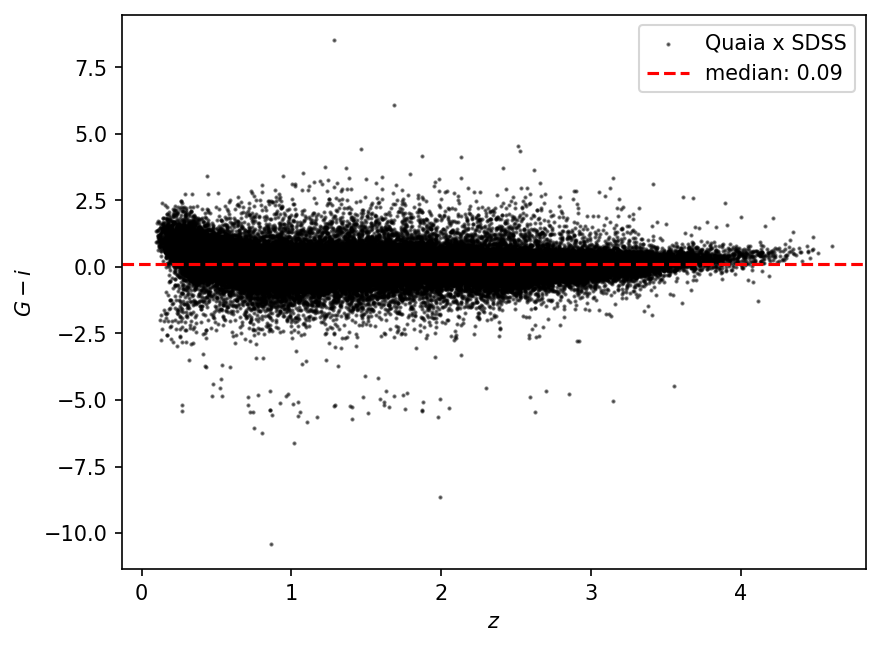

In [32]:
plt.scatter(tab_quaia_with_sdssdr16q_match_cmodel_sorted['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'], s = 1, alpha = 0.5, label = 'Quaia x SDSS', color = 'black')
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')
plt.xlabel('$z$')
plt.ylabel('$G-i$')
# plt.ylim(-7,5)
plt.legend()
plt.show()

_G20.0_zsplit2bin0
[  0.  50. 100.]
zbins: [0.08373538 1.5295195  4.62084557]
n_zbins: 2
zmin: 0.09373538191722569
zmax: 1.5295178890228271
median G-i: 0.10210834228515608 +/- 0.4374922442201094

_G20.0_zsplit2bin1
[  0.  50. 100.]
zbins: [0.08373538 1.5295195  4.62084557]
n_zbins: 2
zmin: 1.529521107673645
zmax: 4.610845565795898
median G-i: 0.07873156433105422 +/- 0.35176092227325245



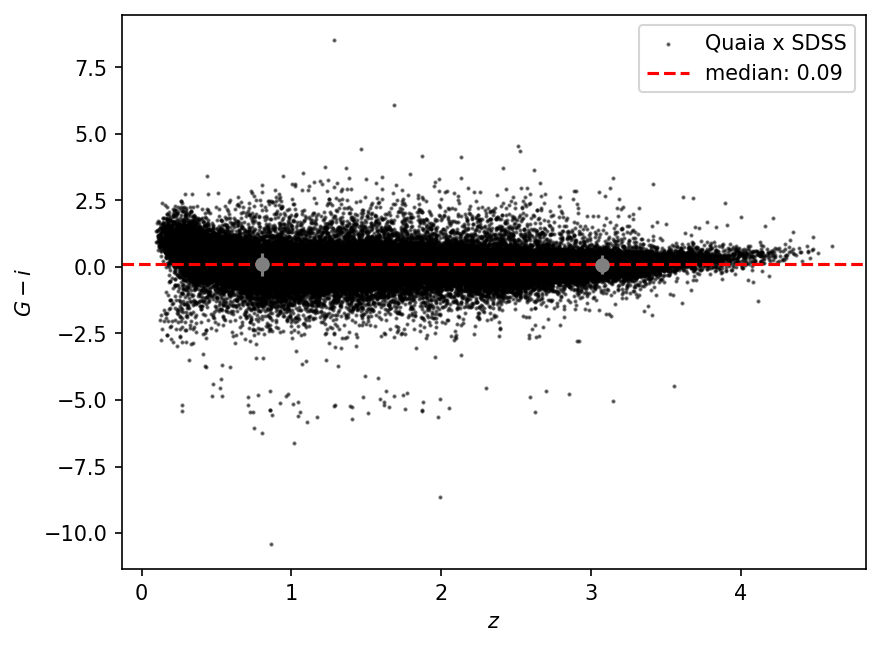

In [20]:
plt.scatter(tab_quaia_with_sdssdr16q_match_cmodel_sorted['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'], s = 1, alpha = 0.5, label = 'Quaia x SDSS', color = 'black')
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')

n_zbins = 2
for i in range(n_zbins):
 #    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 # key_zbin0) = quaia.zbins(G, i, tab_gcat = tab_quaia_with_sdssdr16q_match, data = 'mocks', n_zbins = n_zbins)
    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 key_zbin0, z_bins) = quaia.make_zbins(G, i, False, method = 'zsplit', tab_gcat = tab_quaia_with_sdssdr16q_match_cmodel_sorted, n_zbins = n_zbins)
    yerr = np.std(tab_datahi_mask_zbin0['G-i'])
    print('median G-i: {} +/- {}\n'.format(np.median(tab_datahi_mask_zbin0['G-i']), yerr))
    plt.scatter(quaia.recenter(z_bins)[i], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3, color = 'grey')
    plt.errorbar(quaia.recenter(z_bins)[i], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3, yerr = yerr, color = 'grey')
    
plt.xlabel('$z$')
plt.ylabel('$G-i$')
# plt.ylim(-7,5)
plt.legend()
plt.show()

_G20.0_zsplit4bin0
[  0.  25.  50.  75. 100.]
zbins: [0.08373538 1.036      1.5295195  2.1119864  4.62084557]
n_zbins: 4
zmin: 0.09373538191722569
zmax: 1.0359981060028076
median G-i: 0.12867755371093637 +/- 0.49317418009198866

_G20.0_zsplit4bin1
[  0.  25.  50.  75. 100.]
zbins: [0.08373538 1.036      1.5295195  2.1119864  4.62084557]
n_zbins: 4
zmin: 1.036
zmax: 1.5295178890228271
median G-i: 0.07901636291503777 +/- 0.3723979499626638

_G20.0_zsplit4bin2
[  0.  25.  50.  75. 100.]
zbins: [0.08373538 1.036      1.5295195  2.1119864  4.62084557]
n_zbins: 4
zmin: 1.529521107673645
zmax: 2.111983299255371
median G-i: 0.12197594177246174 +/- 0.35506329728591846

_G20.0_zsplit4bin3
[  0.  25.  50.  75. 100.]
zbins: [0.08373538 1.036      1.5295195  2.1119864  4.62084557]
n_zbins: 4
zmin: 2.1119956970214844
zmax: 4.610845565795898
median G-i: 0.030918212585449467 +/- 0.34913600658563476



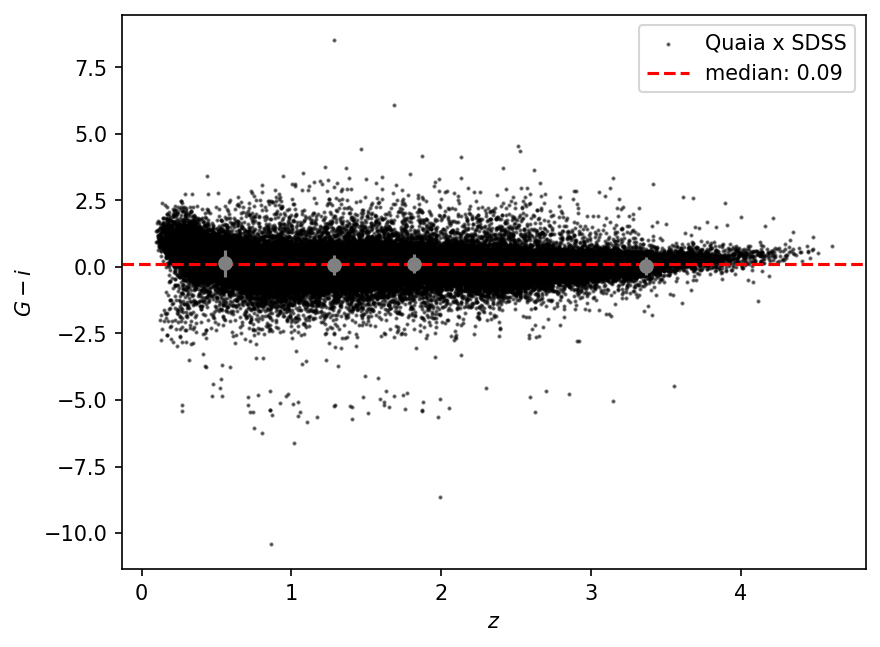

In [21]:
plt.scatter(tab_quaia_with_sdssdr16q_match_cmodel_sorted['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'], s = 1, alpha = 0.5, label = 'Quaia x SDSS', color = 'black')
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')

n_zbins = 4
for i in range(n_zbins):
 #    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 # key_zbin0) = quaia.zbins(G, i, tab_gcat = tab_quaia_with_sdssdr16q_match, data = 'mocks', n_zbins = n_zbins)
    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 key_zbin0, z_bins) = quaia.make_zbins(G, i, False, method = 'zsplit', tab_gcat = tab_quaia_with_sdssdr16q_match_cmodel_sorted, n_zbins = n_zbins)
    yerr = np.std(tab_datahi_mask_zbin0['G-i'])
    print('median G-i: {} +/- {}\n'.format(np.median(tab_datahi_mask_zbin0['G-i']), yerr))
    plt.scatter(quaia.recenter(z_bins)[i], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3, color = 'grey')
    plt.errorbar(quaia.recenter(z_bins)[i], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3, yerr = yerr, color = 'grey')
    
plt.xlabel('$z$')
plt.ylabel('$G-i$')
# plt.ylim(-7,5)
plt.legend()
plt.show()

_G20.0_zmin0.0zmax1.0
zmin: 0.09373538191722569
zmax: 0.9999824166297913
median G-i: 0.13650841613769593 +/- 0.4970269380662777

_G20.0_zmin1.0zmax2.0
zmin: 1.0000180006027222
zmax: 1.9999901056289673
median G-i: 0.10360752868652412 +/- 0.3662011590058419

_G20.0_zmin2.0zmax3.0
zmin: 2.0
zmax: 2.99995493888855
median G-i: 0.018940807800293058 +/- 0.3495309649341743

_G20.0_zmin3.0zmax4.0
zmin: 3.000002861022949
zmax: 3.9925544261932373
median G-i: 0.14697744354248066 +/- 0.3318005645029118



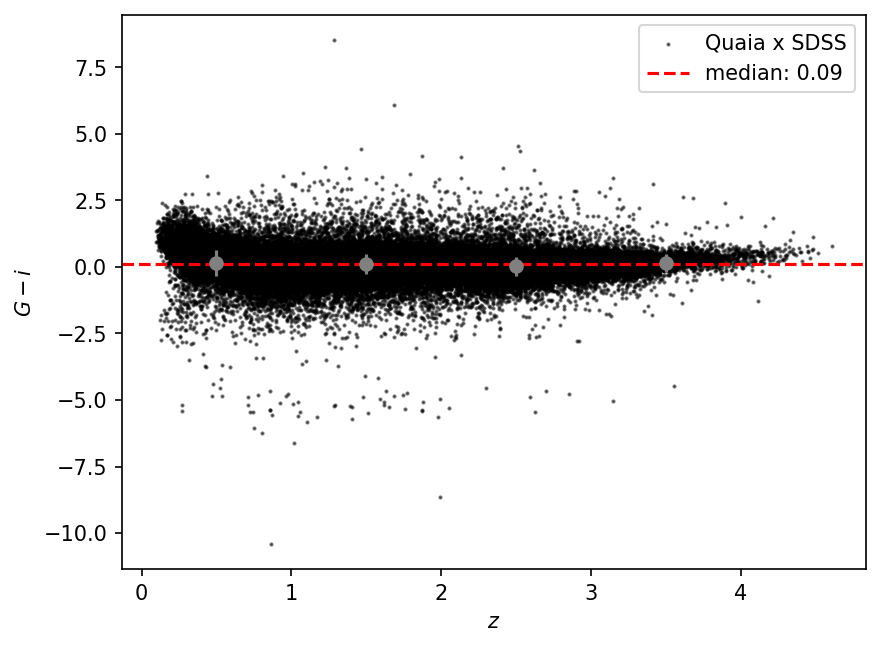

In [22]:
plt.scatter(tab_quaia_with_sdssdr16q_match_cmodel_sorted['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'], s = 1, alpha = 0.5, label = 'Quaia x SDSS', color = 'black')
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')

z_bins = [0.0,1.0,2.0,3.0,4.0]
for bb in range(len(z_bins)-1):
    # i_zbin = (tab_quaia_with_sdssdr16q_match['redshift_quaia'] >= z_bins[bb]) & (tab_quaia_with_sdssdr16q_match['redshift_quaia'] < z_bins[bb+1])
    # tab_gcat_zbin = tab_quaia_with_sdssdr16q_match[i_zbin]
 #    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 # key_zbin0) = quaia.zbins(G, bb, tab_gcat = tab_quaia_with_sdssdr16q_match, data = 'mocks', n_zbins = None)
    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 key_zbin0, z_bins) = quaia.make_zbins(G, bb, False, method = 'zminzmax', tab_gcat = tab_quaia_with_sdssdr16q_match_cmodel_sorted, z_bins = z_bins)
    yerr = np.std(tab_datahi_mask_zbin0['G-i'])
    print('median G-i: {} +/- {}\n'.format(np.median(tab_datahi_mask_zbin0['G-i']), yerr))
    plt.scatter(quaia.recenter(np.array(z_bins))[bb], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3, color = 'grey')
    plt.errorbar(quaia.recenter(np.array(z_bins))[bb], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3, yerr = yerr, color = 'grey')
    
plt.xlabel('$z$')
plt.ylabel('$G-i$')
# plt.ylim(-7,5)
plt.legend()
plt.show()

### Try adding a colormap

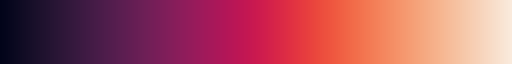

In [29]:
cmap = sns.color_palette("rocket", as_cmap = True)
cmap

_G20.0_zmin0.0zmax1.0
zmin: 0.09373538191722569
zmax: 0.9999824166297913
median G-i: 0.13650841613769593 +/- 0.4970269380662777

_G20.0_zmin1.0zmax2.0
zmin: 1.0000180006027222
zmax: 1.9999901056289673
median G-i: 0.10360752868652412 +/- 0.3662011590058419

_G20.0_zmin2.0zmax3.0
zmin: 2.0
zmax: 2.99995493888855
median G-i: 0.018940807800293058 +/- 0.3495309649341743

_G20.0_zmin3.0zmax4.0
zmin: 3.000002861022949
zmax: 3.9925544261932373
median G-i: 0.14697744354248066 +/- 0.3318005645029118



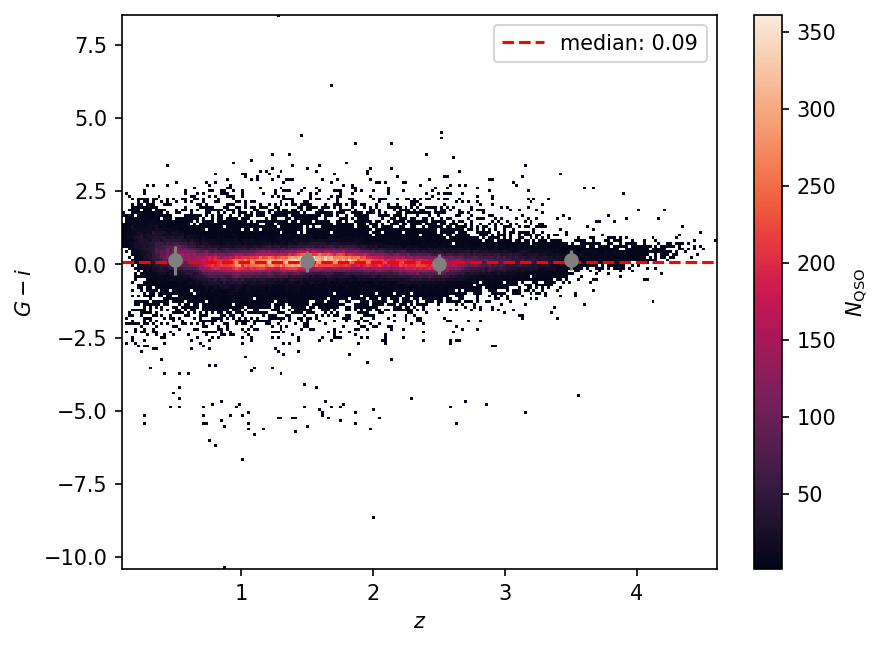

In [74]:
plt.hist2d(tab_quaia_with_sdssdr16q_match_cmodel_sorted['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'], label = 'Quaia x SDSS', bins = [200,200], cmap = cmap, cmin = 1)
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')
plt.colorbar(label='$N_\mathrm{QSO}$')

z_bins = [0.0,1.0,2.0,3.0,4.0]
for bb in range(len(z_bins)-1):
    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 key_zbin0, z_bins) = quaia.make_zbins(G, bb, False, method = 'zminzmax', tab_gcat = tab_quaia_with_sdssdr16q_match_cmodel_sorted, z_bins = z_bins)
    yerr = np.std(tab_datahi_mask_zbin0['G-i'])
    print('median G-i: {} +/- {}\n'.format(np.median(tab_datahi_mask_zbin0['G-i']), yerr))
    plt.scatter(quaia.recenter(np.array(z_bins))[bb], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3, color = 'grey')
    plt.errorbar(quaia.recenter(np.array(z_bins))[bb], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3, yerr = yerr, color = 'grey')
    
plt.xlabel('$z$')
plt.ylabel('$G-i$')
# plt.ylim(-7,5)
plt.legend()
plt.show()

## Find the objects that are outliers

In [23]:
ind = np.abs(tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'])>11
tab_quaia_with_sdssdr16q_match_cmodel_sorted['G-i'][ind]

<Column name='G-i' dtype='float64' unit='mag' description='\\emph{Gaia} $G$-band mean magnitude' length=0>

In [24]:
tab_quaia_with_sdssdr16q_match_cmodel_sorted[ind]

source_id,unwise_objid,redshift_quaia,redshift_quaia_err,ra,dec,l,b,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,mag_w1_vg,mag_w2_vg,pm,pmra,pmdec,pmra_error,pmdec_error,sdss_SDSS_NAME,sdss_RA,sdss_DEC,sdss_PLATE,sdss_MJD,sdss_FIBERID,sdss_AUTOCLASS_PQN,sdss_AUTOCLASS_DR14Q,sdss_IS_QSO_QN,sdss_Z_QN,sdss_RANDOM_SELECT,sdss_Z_10K,sdss_Z_CONF_10K,sdss_PIPE_CORR_10K,sdss_IS_QSO_10K,sdss_THING_ID,sdss_Z_VI,sdss_Z_CONF,sdss_CLASS_PERSON,sdss_Z_DR12Q,sdss_IS_QSO_DR12Q,sdss_Z_DR7Q_SCH,sdss_IS_QSO_DR7Q,sdss_Z_DR6Q_HW,sdss_Z_DR7Q_HW,sdss_IS_QSO_FINAL,sdss_Z,sdss_SOURCE_Z,sdss_Z_PIPE,sdss_ZWARNING,sdss_OBJID,sdss_Z_PCA,sdss_ZWARN_PCA,sdss_DELTACHI2_PCA,sdss_Z_HALPHA,sdss_ZWARN_HALPHA,sdss_DELTACHI2_HALPHA,sdss_Z_HBETA,sdss_ZWARN_HBETA,sdss_DELTACHI2_HBETA,sdss_Z_MGII,sdss_ZWARN_MGII,sdss_DELTACHI2_MGII,sdss_Z_CIII,sdss_ZWARN_CIII,sdss_DELTACHI2_CIII,sdss_Z_CIV,sdss_ZWARN_CIV,sdss_DELTACHI2_CIV,sdss_Z_LYA,sdss_ZWARN_LYA,sdss_DELTACHI2_LYA,sdss_Z_LYAWG,sdss_Z_DLA,sdss_NHI_DLA,sdss_CONF_DLA,sdss_BAL_PROB,sdss_BI_CIV,sdss_ERR_BI_CIV,sdss_AI_CIV,sdss_ERR_AI_CIV,sdss_BI_SIIV,sdss_ERR_BI_SIIV,sdss_AI_SIIV,sdss_ERR_AI_SIIV,sdss_BOSS_TARGET1,sdss_EBOSS_TARGET0,sdss_EBOSS_TARGET1,sdss_EBOSS_TARGET2,sdss_ANCILLARY_TARGET1,sdss_ANCILLARY_TARGET2,sdss_NSPEC_SDSS,sdss_NSPEC_BOSS,sdss_NSPEC,sdss_PLATE_DUPLICATE,sdss_MJD_DUPLICATE,sdss_FIBERID_DUPLICATE,sdss_SPECTRO_DUPLICATE,sdss_SKYVERSION,sdss_RUN_NUMBER,sdss_RERUN_NUMBER,sdss_CAMCOL_NUMBER,sdss_FIELD_NUMBER,sdss_ID_NUMBER,sdss_LAMBDA_EFF,sdss_ZOFFSET,sdss_XFOCAL,sdss_YFOCAL,sdss_CHUNK,sdss_TILE,sdss_PLATESN2,sdss_PSFFLUX,sdss_PSFFLUX_IVAR,sdss_PSFMAG,sdss_PSFMAGERR,sdss_EXTINCTION,sdss_M_I,sdss_SN_MEDIAN_ALL,sdss_GALEX_MATCHED,sdss_FUV,sdss_FUV_IVAR,sdss_NUV,sdss_NUV_IVAR,sdss_UKIDSS_MATCHED,sdss_YFLUX,sdss_YFLUX_ERR,sdss_JFLUX,sdss_JFLUX_ERR,sdss_HFLUX,sdss_HFLUX_ERR,sdss_KFLUX,sdss_KFLUX_ERR,sdss_W1_FLUX,sdss_W1_FLUX_IVAR,sdss_W1_MAG,sdss_W1_MAG_ERR,sdss_W1_CHI2,sdss_W1_FLUX_SNR,sdss_W1_SRC_FRAC,sdss_W1_EXT_FLUX,sdss_W1_EXT_FRAC,sdss_W1_NPIX,sdss_W2_FLUX,sdss_W2_FLUX_IVAR,sdss_W2_MAG,sdss_W2_MAG_ERR,sdss_W2_CHI2,sdss_W2_FLUX_SNR,sdss_W2_SRC_FRAC,sdss_W2_EXT_FLUX,sdss_W2_EXT_FRAC,sdss_W2_NPIX,sdss_FIRST_MATCHED,sdss_FIRST_FLUX,sdss_FIRST_SNR,sdss_SDSS2FIRST_SEP,sdss_JMAG,sdss_JMAG_ERR,sdss_JSNR,sdss_JRDFLAG,sdss_HMAG,sdss_HMAG_ERR,sdss_HSNR,sdss_HRDFLAG,sdss_KMAG,sdss_KMAG_ERR,sdss_KSNR,sdss_KRDFLAG,sdss_SDSS2MASS_SEP,sdss_2RXS_ID,sdss_2RXS_RA,sdss_2RXS_DEC,sdss_2RXS_SRC_FLUX,sdss_2RXS_SRC_FLUX_ERR,sdss_SDSS2ROSAT_SEP,sdss_XMM_SRC_ID,sdss_XMM_RA,sdss_XMM_DEC,sdss_XMM_SOFT_FLUX,sdss_XMM_SOFT_FLUX_ERR,sdss_XMM_HARD_FLUX,sdss_XMM_HARD_FLUX_ERR,sdss_XMM_TOTAL_FLUX,sdss_XMM_TOTAL_FLUX_ERR,sdss_XMM_TOTAL_LUM,sdss_SDSS2XMM_SEP,sdss_GAIA_MATCHED,sdss_GAIA_DESIGNATION,sdss_GAIA_RA,sdss_GAIA_DEC,sdss_GAIA_PARALLAX,sdss_GAIA_PARALLAX_ERR,sdss_GAIA_PM_RA,sdss_GAIA_PM_RA_ERR,sdss_GAIA_PM_DEC,sdss_GAIA_PM_DEC_ERR,sdss_GAIA_G_MAG,sdss_GAIA_G_FLUX_SNR,sdss_GAIA_BP_MAG,sdss_GAIA_BP_FLUX_SNR,sdss_GAIA_RP_MAG,sdss_GAIA_RP_FLUX_SNR,sdss_SDSS2GAIA_SEP,ObjID,cModelMag_i,G-i
,,,,deg,deg,deg,deg,mag,mag,mag,mag,mag,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,mag
int64,bytes16,float64,float64,float64,float64,float64,float64,float32,float32,float32,float64,float64,float64,float64,float64,float32,float32,bytes18,float64,float64,int32,int32,int16,bytes6,bytes6,int16,float64,int16,float64,int16,int16,int16,int64,float64,int16,int16,float64,int16,float64,int16,float64,float64,int16,float64,bytes12,float64,int32,bytes19,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float32,float64[5],float64[5],float64[5],float32,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int32,int32,int32,int32[

In [25]:
np.sort(tab_quaia_with_sdssdr16q_match_cmodel_sorted['cModelMag_i'])

11.39948
13.48555
14.70995
14.77147
14.8969
15.1003
15.10441
15.11036
15.15737
15.16336
15.18754
